<a href="https://colab.research.google.com/github/davesagit123/blank-app/blob/main/lca_sectional_classes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Latent Class Analysis (LCA) --- SECTIONAL MULTI-CRITERIA ANALYSIS
Adapted from the DOD/EM/PP cells.
"""
import re
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.width', 220)
pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True})
np.set_printoptions(suppress=True)

try:
    from IPython.display import display
except ImportError:
    def display(x): print(x.to_string() if hasattr(x, 'to_string') else x)

# ---- 1. CONFIG ------------------------------------------------------------
METRICS = ['Runner Time', 'Early Pace', 'L800m', 'L600m', 'L400m', 'L200m']
LOWER_BETTER = {m: True for m in METRICS}
PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#7f7f7f', '#bcbd22']

# ---- 2. RAW DATA (Headerless rows) ----------------------------------------
RAW_LAST3 = """
Middle Earth	-5.39L	42	-2.05L	-1.84L	-1.36L	-0.58L
Attrition	-3.89L	41	-2.01L	-1.47L	-0.78L	-0.20L
Kingswood	-11.37L	58	-2.62L	-2.08L	-1.38L	-0.46L
Knight's Choice	-2.99L	38	-3.43L	-2.50L	-0.99L	-0.47L
Royal Supremacy	-10.05L	60	-2.57L	-1.98L	-0.78L	-0.36L
Wootton Verni	-12.80L	65	-2.15L	-1.40L	-0.73L	+0.00L
Barnavara	-17.26L	76	-3.38L	-2.50L	-1.07L	-0.22L
Soulcombe	-26.18L	89	-2.13L	-1.37L	-1.07L	-0.42L
Just Folk	-10.34L	62	-2.24L	-1.80L	-0.92L	-0.12L
Yellow Jersey	-19.61L	57	-4.32L	-3.84L	-2.36L	-0.91L
Okita Soushi	-6.24L	39	-1.56L	-1.19L	-0.74L	-0.16L
River Of Stars	-12.45L	54	-3.06L	-2.18L	-1.21L	-0.43L
Deakin	-8.73L	59	-2.11L	-1.37L	-0.66L	+0.01L
Zahrann	+3.05L	9	-2.75L	-2.64L	-1.76L	-0.70L
Zakouma	-17.45L	70	-3.91L	-2.47L	-1.43L	-0.39L
First Chorus	-3.55L	28	-2.69L	-2.06L	-1.41L	-0.48L


"""

RAW_LAST10 = """
Middle Earth	-9.32L	54	-2.28L	-1.66L	-1.00L	-0.41L
Attrition	-4.82L	50	-1.71L	-1.26L	-0.61L	-0.16L
Kingswood	-11.37L	58	-2.62L	-2.08L	-1.38L	-0.46L
Knight's Choice	-8.28L	59	-2.18L	-1.43L	-0.61L	-0.15L
Royal Supremacy	-12.23L	61	-1.98L	-1.63L	-0.94L	-0.30L
Wootton Verni	-13.42L	57	-2.92L	-2.28L	-1.48L	-0.39L
Barnavara	-17.26L	76	-3.38L	-2.50L	-1.07L	-0.22L
Soulcombe	-16.09L	60	-3.03L	-2.27L	-1.51L	-0.61L
Just Folk	-6.42L	69	-1.04L	-0.67L	-0.11L	+0.29L
Yellow Jersey	-19.61L	57	-4.32L	-3.84L	-2.36L	-0.91L
Okita Soushi	-11.77L	68	-1.40L	-0.75L	-0.30L	+0.08L
River Of Stars	-11.83L	57	-2.13L	-1.44L	-0.80L	-0.26L
Deakin	-6.79L	50	-2.28L	-1.59L	-0.94L	-0.23L
Zahrann	+3.05L	9	-2.75L	-2.64L	-1.76L	-0.70L
Zakouma	-5.61L	45	-2.85L	-2.15L	-1.25L	-0.26L
First Chorus	+0.12L	26	-2.27L	-2.00L	-1.48L	-0.71L


"""

# ---- 3. DATA PIPELINE -----------------------------------------------------
def _num(s):
    try: return float(s.strip().upper().rstrip('L'))
    except (ValueError, AttributeError): return np.nan

def parse_sectional(raw, metrics):
    rows = []
    for line in raw.strip().splitlines():
        line = line.strip()
        if not line: continue
        parts = re.split(r'\t+', line)
        if len(parts) < len(metrics) + 1: continue
        rows.append((parts[0].strip(), *[_num(x) for x in parts[1:len(metrics)+1]]))
    df = pd.DataFrame(rows, columns=['Runner', *metrics])
    for m in metrics: df[m] = df[m].fillna(df[m].mean() if not df[m].isnull().all() else 0)
    return df

def zscore(df, m):
    v = df[m].to_numpy(dtype=float); sd = v.std(ddof=0)
    return np.zeros_like(v) if sd == 0 else (v - v.mean()) / sd

class GaussianMixtureLCA:
    def __init__(self, n_components=3, tol=1e-5, max_iter=500, seed=0): self.K, self.tol, self.max_iter, self.seed = int(n_components), float(tol), int(max_iter), int(seed)
    def _lse(self, a): m = a.max(axis=1, keepdims=True); return (m.squeeze(-1) + np.log(np.sum(np.exp(a - m), axis=1)))
    def fit(self, X):
        X = np.asarray(X, dtype=float); n, p = X.shape; rng = np.random.default_rng(self.seed)
        idx = rng.choice(n, min(n, self.K), replace=False); self.means_, self.weights_, self.covs_ = X[idx].copy(), np.full(self.K, 1.0/self.K), np.full((self.K, p), 1.0)
        newll = -np.inf
        for it in range(self.max_iter):
            diff = X[:, None, :] - self.means_[None, :, :]
            log_resp = (np.log(self.weights_[None, :] + 1e-300) - 0.5*np.log((2*np.pi)**p * np.prod(self.covs_, axis=1))[None, :] - 0.5*np.sum(diff**2 / self.covs_[None, :, :], axis=2))
            log_resp -= self._lse(log_resp)[:, None]; resp = np.exp(np.clip(log_resp, -700, np.inf))
            ll = self._lse(log_resp).sum()
            if abs(ll - newll) < self.tol: break
            newll, Nk = ll, resp.sum(axis=0) + 1e-9; self.weights_ = Nk / n; self.means_ = (resp.T @ X) / Nk[:, None]
            self.covs_ = np.sum(resp[:, :, None] * diff**2, axis=0) / Nk[:, None] + 1e-2
        return self
    def predict(self, X):
        X = np.asarray(X, dtype=float); n, p = X.shape; diff = X[:, None, :] - self.means_[None, :, :]
        log_resp = (np.log(self.weights_[None, :] + 1e-300) - 0.5*np.log((2*np.pi)**p * np.prod(self.covs_, axis=1))[None, :] - 0.5*np.sum(diff**2 / self.covs_[None, :, :], axis=2))
        return np.argmax(log_resp, axis=1)

def stable_order(gm): return sorted(range(gm.means_.shape[0]), key=lambda j: gm.means_[j].mean())

def save_plots(data, gm, assign, out_dir='./figures/'):
    os.makedirs(out_dir, exist_ok=True); order = stable_order(gm)
    # Profiles
    plt.figure(figsize=(8, 5))
    for i, idx in enumerate(order):
        plt.plot(METRICS, gm.means_[idx], marker='o', label=f'Class {i+1}', color=PALETTE[i%len(PALETTE)])
    plt.legend(); plt.title('LCA Profiles (Z-Scores)'); plt.savefig(f'{out_dir}lca_profiles.png'); plt.close()
    # Heatmap
    sorted_idx = np.argsort(assign)
    plt.figure(figsize=(10, 6)); plt.imshow(data[METRICS].iloc[sorted_idx].T, aspect='auto', cmap='RdYlGn_r')
    plt.title('Performance Heatmap'); plt.savefig(f'{out_dir}lca_heatmap.png'); plt.close()

def run(dataset):
    data = parse_sectional(dataset, METRICS)
    Z = np.column_stack([zscore(data, m) for m in METRICS])
    gm = GaussianMixtureLCA(n_components=3 if len(data)>5 else 2, seed=42).fit(Z)
    assign = gm.predict(Z); order = stable_order(gm); cmap = {old: f'Class {i+1}' for i, old in enumerate(order)}
    final_assign = np.array([cmap[a] for a in assign])
    save_plots(data, gm, assign)
    return data.assign(Class=final_assign)

def main():
    for d, n in [(RAW_LAST3, "LAST 3"), (RAW_LAST10, "LAST 10")]:
        print(f"\nLCA Results for {n}:"); display(run(d))

if __name__ == '__main__': main()


LCA Results for LAST 3:


,Runner,Runner Time,Early Pace,L800m,L600m,L400m,L200m,Class
0,Middle Earth,-5.39,42.0,-2.05,-1.84,-1.36,-0.58,Class 2
1,Attrition,-3.89,41.0,-2.01,-1.47,-0.78,-0.20,Class 3
2,Kingswood,-11.37,58.0,-2.62,-2.08,-1.38,-0.46,Class 1
3,Knight's Choice,-2.99,38.0,-3.43,-2.50,-0.99,-0.47,Class 1
4,Royal Supremacy,-10.05,60.0,-2.57,-1.98,-0.78,-0.36,Class 2
5,Wootton Verni,-12.80,65.0,-2.15,-1.40,-0.73,0.00,Class 3
6,Barnavara,-17.26,76.0,-3.38,-2.50,-1.07,-0.22,Class 1
7,Soulcombe,-26.18,89.0,-2.13,-1.37,-1.07,-0.42,Class 1
8,Just Folk,-10.34,62.0,-2.24,-1.80,-0.92,-0.12,Class 3
9,Yellow Jersey,-19.61,57.0,-4.32,-3.84,-2.36,-0.91,Class 1



LCA Results for LAST 10:


,Runner,Runner Time,Early Pace,L800m,L600m,L400m,L200m,Class
0,Middle Earth,-9.32,54.0,-2.28,-1.66,-1.00,-0.41,Class 1
1,Attrition,-4.82,50.0,-1.71,-1.26,-0.61,-0.16,Class 2
2,Kingswood,-11.37,58.0,-2.62,-2.08,-1.38,-0.46,Class 1
3,Knight's Choice,-8.28,59.0,-2.18,-1.43,-0.61,-0.15,Class 1
4,Royal Supremacy,-12.23,61.0,-1.98,-1.63,-0.94,-0.30,Class 1
5,Wootton Verni,-13.42,57.0,-2.92,-2.28,-1.48,-0.39,Class 1
6,Barnavara,-17.26,76.0,-3.38,-2.50,-1.07,-0.22,Class 1
7,Soulcombe,-16.09,60.0,-3.03,-2.27,-1.51,-0.61,Class 1
8,Just Folk,-6.42,69.0,-1.04,-0.67,-0.11,0.29,Class 3
9,Yellow Jersey,-19.61,57.0,-4.32,-3.84,-2.36,-0.91,Class 1



LCA Results for LAST 3:


,Runner,Runner Time,Early Pace,L800m,L600m,L400m,L200m,Class
0,Middle Earth,-5.39,42.0,-2.05,-1.84,-1.36,-0.58,Class 2
1,Attrition,-3.89,41.0,-2.01,-1.47,-0.78,-0.20,Class 3
2,Kingswood,-11.37,58.0,-2.62,-2.08,-1.38,-0.46,Class 1
3,Knight's Choice,-2.99,38.0,-3.43,-2.50,-0.99,-0.47,Class 1
4,Royal Supremacy,-10.05,60.0,-2.57,-1.98,-0.78,-0.36,Class 2
5,Wootton Verni,-12.80,65.0,-2.15,-1.40,-0.73,0.00,Class 3
6,Barnavara,-17.26,76.0,-3.38,-2.50,-1.07,-0.22,Class 1
7,Soulcombe,-26.18,89.0,-2.13,-1.37,-1.07,-0.42,Class 1
8,Just Folk,-10.34,62.0,-2.24,-1.80,-0.92,-0.12,Class 3
9,Yellow Jersey,-19.61,57.0,-4.32,-3.84,-2.36,-0.91,Class 1



LCA Results for LAST 10:


,Runner,Runner Time,Early Pace,L800m,L600m,L400m,L200m,Class
0,Middle Earth,-9.32,54.0,-2.28,-1.66,-1.00,-0.41,Class 1
1,Attrition,-4.82,50.0,-1.71,-1.26,-0.61,-0.16,Class 2
2,Kingswood,-11.37,58.0,-2.62,-2.08,-1.38,-0.46,Class 1
3,Knight's Choice,-8.28,59.0,-2.18,-1.43,-0.61,-0.15,Class 1
4,Royal Supremacy,-12.23,61.0,-1.98,-1.63,-0.94,-0.30,Class 1
5,Wootton Verni,-13.42,57.0,-2.92,-2.28,-1.48,-0.39,Class 1
6,Barnavara,-17.26,76.0,-3.38,-2.50,-1.07,-0.22,Class 1
7,Soulcombe,-16.09,60.0,-3.03,-2.27,-1.51,-0.61,Class 1
8,Just Folk,-6.42,69.0,-1.04,-0.67,-0.11,0.29,Class 3
9,Yellow Jersey,-19.61,57.0,-4.32,-3.84,-2.36,-0.91,Class 1



--- Displaying Fresh Plot: lca_profiles.png ---


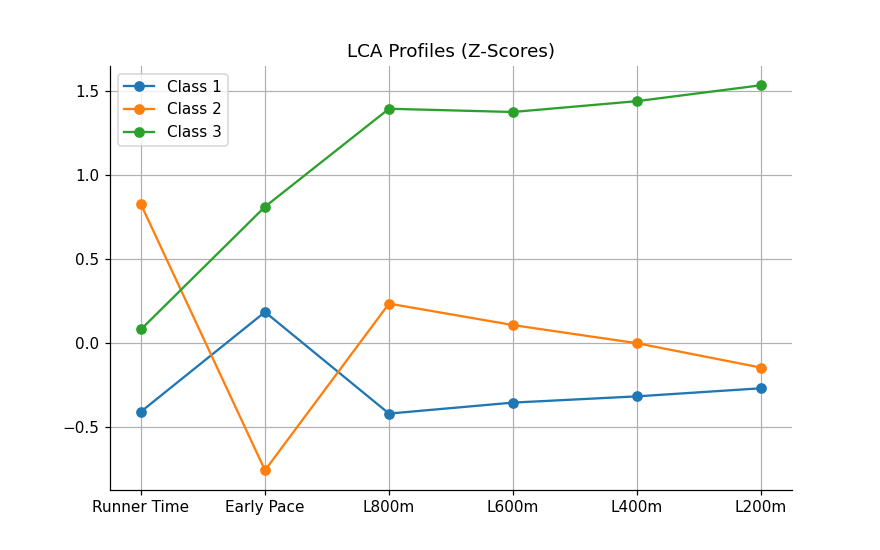


--- Displaying Fresh Plot: lca_heatmap.png ---


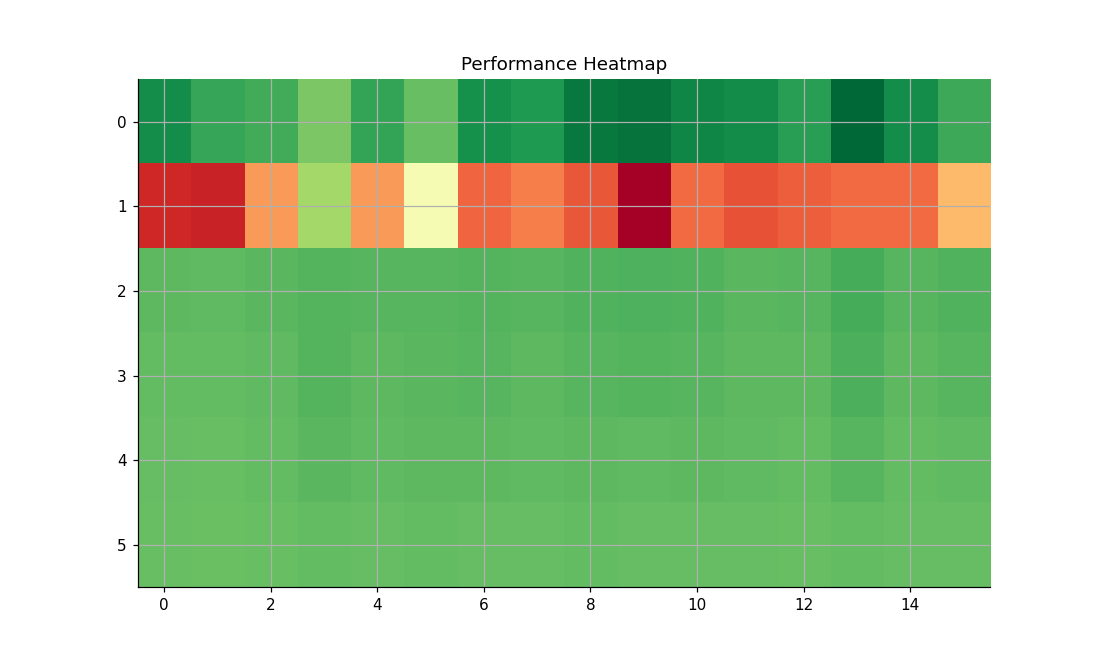

In [21]:
import os
import shutil
from IPython.display import Image, display

# 1. Regenerate plots using the current main() logic
# This ensures the files in ./figures/ are exactly from the new data
try:
    # Clear the figures directory first
    fig_path = './figures/'
    if os.path.exists(fig_path):
        shutil.rmtree(fig_path)
    os.makedirs(fig_path)

    # Re-run main to populate ./figures/ with Middle Earth data plots
    main()

    # 2. Specifically look for and display the fresh images
    found_any = False
    for fig_name in ['lca_profiles.png', 'lca_heatmap.png']:
        full_path = os.path.join(fig_path, fig_name)
        if os.path.exists(full_path):
            print(f"\n--- Displaying Fresh Plot: {fig_name} ---")
            display(Image(filename=full_path))
            found_any = True

    if not found_any:
        print("\nNote: Tables were generated, but plots were not saved to disk. Check if save_plots() is being called inside run().")

except Exception as e:
    print(f"Error generating visualizations: {e}")